In [124]:
import numpy as np
import matplotlib.pyplot as plt

## Tarea 1

1.- Haga las gráficas de las siguientes función \$f(x)=cot(x)\$ en el intervalo \$[-4\pi,4\pi]\$. La gráfica no deben tener líneas verticales.

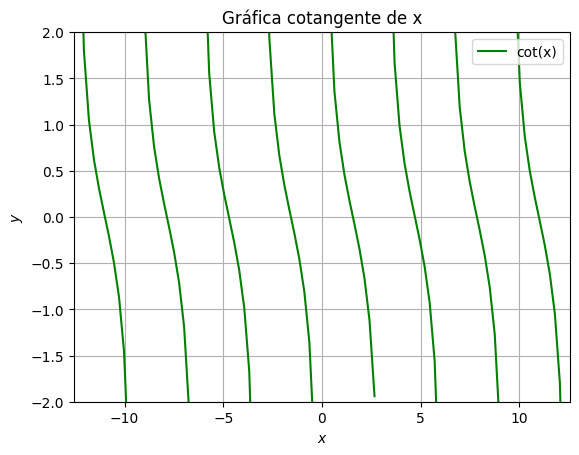

In [125]:
x = np.linspace(-4*np.pi,4*np.pi,100)
y = 1/np.tan(x)

y[:-1][np.diff(y)>0]=np.nan

plt.plot(x,y, label='cot(x)', color='green')

plt.title(r'Gráfica cotangente de x')
plt.xlim([x[0],x[-1]]) , plt.ylim([-2,2])
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.legend(),plt.grid()
plt.show()

____________

2.- Genere una función y la gráfica de 
$$
f(x)=
    \begin{cases}
    1, & \text{si } x \in[n, n+1) \text{ par}\\
    0, & \text{si } x \in[n, n+1) \text{ impar}
    \end{cases}
$$
donde \$n\$ es la parte entera de \$x\$

In [126]:
def f(x):
    y = np.zeros_like(x)

    for i in range(len(x)):
        #La función int en números negativos tomaría n tal que x pertenece al intervalo (n-1,n]; para solucionarlo
        # definimos a (n va a ser par o impar sin importar su signo)
        a = np.abs(x[i])
        if int(a)%2==0:
            y[i]=1
        else:
            y[i]=0
    return y


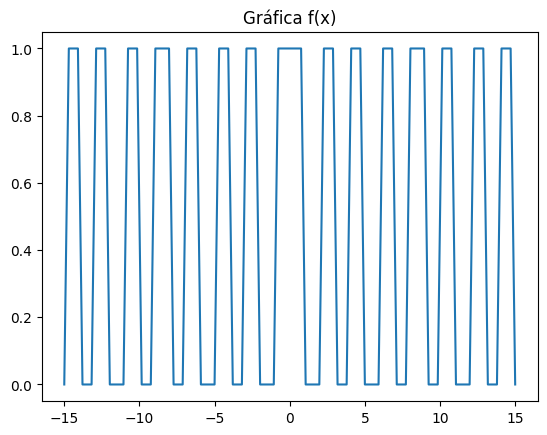

In [127]:
x = np.linspace(-15,15,100)
Y = f(x)


#Gráfica de la función
plt.plot(x,Y,)
plt.title(r'Gráfica f(x)')

plt.show()

_________

3.- Realice la gráfica de 
$$
f(x)=\sum_{n=0}^{N} \frac{(-1)^n}{(2n+1)^2}\sin((2n+1)x)
$$
para \$N=3,5,10,20,30.\$

In [128]:
def f2(X,N):
    y = np.zeros_like(X)
    for i in range(len(X)):
        a = 0
        x = X[i]
        for j in range(N+1):   #Nos asegura que la suma vaya de 0 hasta N
            a = a + ((-1)**j / (2*j + 1)**2)*np.sin((2*j + 1)*x)
        y[i] = a
    return y

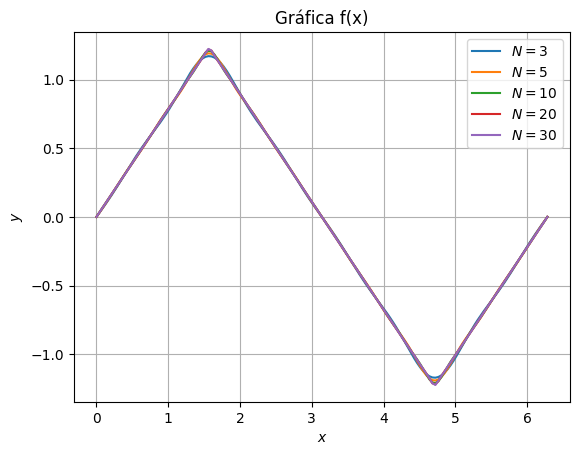

In [129]:
#
x = np.linspace(0,2*np.pi,150)
N1, N2, N3, N4, N5 = 3, 5, 10, 20, 30

y1 = f2(x,N1)
y2 = f2(x,N2)
y3 = f2(x,N3)
y4 = f2(x,N4)
y5 = f2(x,N5)

#Generación de gráficas
plt.plot(x,y1, label=r'$N=3$')
plt.plot(x,y2, label=r'$N=5$')
plt.plot(x,y3, label=r'$N=10$')
plt.plot(x,y4, label=r'$N=20$')
plt.plot(x,y5, label=r'$N=30$')
plt.title(r'Gráfica f(x)')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.legend()
plt.show()


 ____________

4.- Utilice las bibliotecas de scipy para realizar las gráficas de: 

&nbsp;&nbsp;&nbsp;&nbsp;(a) La función de Airy $Ai(x)$ en el intervalo $[-20, 10]$  
&nbsp;&nbsp;&nbsp;&nbsp;(b) Función de Bessel de primera especie $J_n(x)$ para $n = 0, 1, 2, 3$  
&nbsp;&nbsp;&nbsp;&nbsp;(c) Función esférica de Bessel de primera especie $j_n(x)$ para $n = 0, 1, 2, 3$


In [130]:
from scipy import special as sp

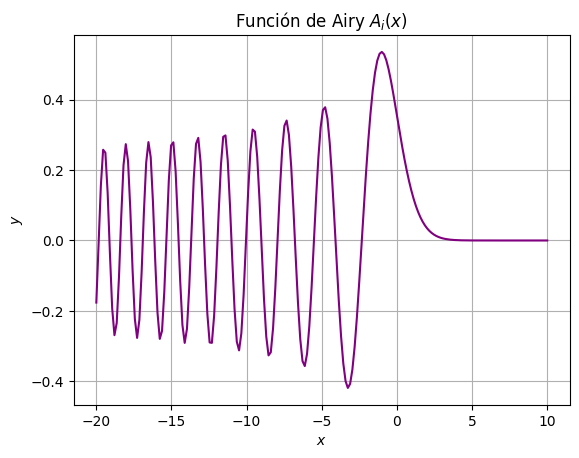

In [131]:
#a) Función de Airy
x = np.linspace(-20, 10, 200)
Ai, Aip, Bi, Bip = sp.airy(x)

plt.plot(x,Ai, label=r'$A_i(x)$', color='purple')
plt.title(r'Función de Airy $A_i(x)$')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.show()

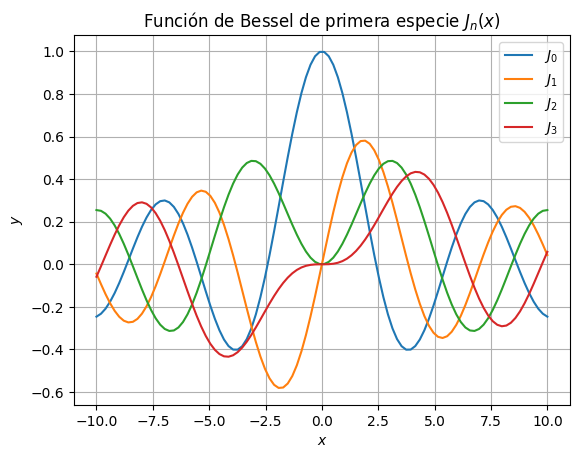

In [132]:
# b) Función de Bessel de primera especie
x = np.linspace(-10, 10, 100)

for n in range(4):
    plt.plot(x, sp.jv(n, x), label=f'$J_{n}$')
plt.title(r'Función de Bessel de primera especie $J_n(x)$')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.legend()
plt.show()

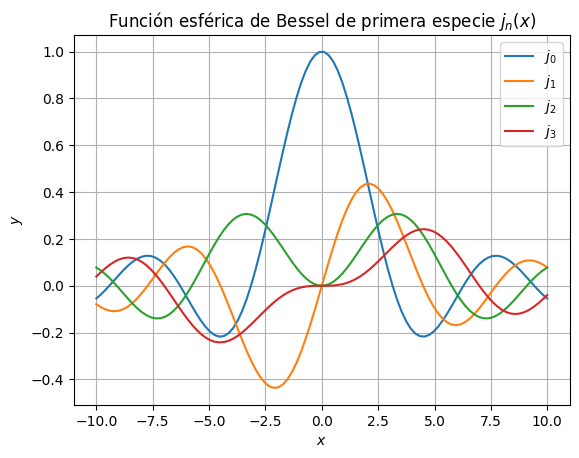

In [133]:
# c) Función esférica de Bessel de primera especie
x = np.linspace(-10, 10, 100)

for n in range(4):
    plt.plot(x, sp.spherical_jn(n, x), label=f'$j_{n}$')
plt.title(r'Función esférica de Bessel de primera especie $j_n(x)$')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.legend()
plt.show()

_______________

5.- Utilizando las notas de clase y notebooks de la página del curso genere una función que calcule derivadas numéricas que consideren una precisión en las que se desprecien términos iguales o mayores a $h^5$ en el espaciado de la malla del dominio de la función. Muestra que tus funciones trabajan bien con un ejemplo en el cual calcules su derivada de forma analítica.

In [134]:
from pylab import *

In [135]:
#Función que calcula derivadas
def deriv_h5(f,x):
    f_prima = zeros(len(f))
    h = x[1] - x[0]
    doceh = 12*h
    for i in range(2,len(f)-2): #Excluye del arreglo los dos primeros y los dos últimos puntos
        f_prima[i] = ( -f[i+2]+ 8*(f[i+1]-f[i-1]) +f[i-2] )/(doceh)
    
    # Cálculo de los puntos extremos
    f_prima[0] = ( (-25/12)*f[0] + 4*f[1] - 3*f[2] + (4/3)*f[3] - 0.25*f[4] )/h
    f_prima[1] = ( (-25/12)*f[1] + 4*f[2] - 3*f[3] + (4/3)*f[4] - 0.25*f[5] )/h
    f_prima[-1] = -( (-25/12)*f[-1] + 4*f[-2] - 3*f[-3] + (4/3)*f[-4] - 0.25*f[-5] )/h
    f_prima[-2] = -( (-25/12)*f[-2] + 4*f[-3] - 3*f[-4] + (4/3)*f[-5] - 0.25*f[-6] )/h
    
    return f_prima

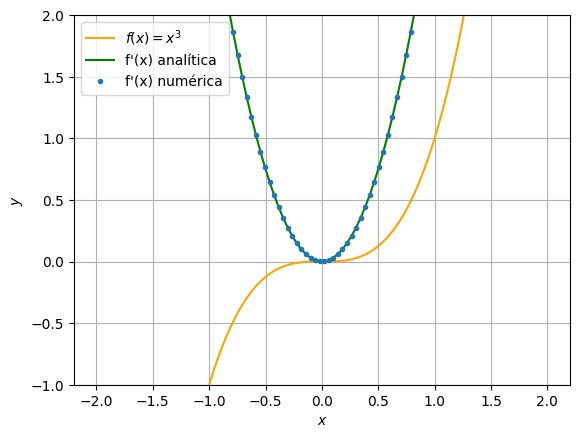

In [136]:
x = np.linspace(-2,2,100)
F = x**3
DF = 3*(x**2) #Derivada analítica

F_h5 = deriv_h5(F,x)

plt.plot(x,F, label=r'$f(x)=x^3$', color='orange')
plt.plot(x,DF, label="f'(x) analítica", color='green')
plt.plot(x,F_h5,'.', label="f'(x) numérica")
plt.ylim([-1,2])
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.legend()
plt.show()

_______________

6.- Calcule la derivada analítica de las funciones $f(x)=e^{-(x/2)^2}cos(4x)$ con $x\in[-5,5]$ y $g(x)=\frac{2}{x^6}+\frac{1}{x^{12}}$ con $x\in[0.5,5]$. Realice las gráficas de las funciones y sus primeras dos derivadas. Con los algoritmos vistos en clase (los que desprecian términos mayores a $O(h^2)$), encuentra la derivada numérica de dichas funciones con error menor a $10^{-4}$ para cualquier punto al comparar con las derivadas analíticas. También realice una comparación utilizando la función derivada del problema anterior. Es decir, haga una gráfica en la que se muestre $|f´_{analitica}(x)-f´_{h^2}|$ y $|f´_{analitica}(x)-f´_{h^4}|$, así como para las segundas derivadas, y muestre que el error es menor a $10^{-4}$ en todo el intervalo con su valor de $h$ respectivo.

In [137]:
#Función que calcula derivadas (se desprecian términos mayores a h^2)
def deriv_sim(f,x):
    df = np.zeros_like(f)
    for i in range(1,len(x)-1):
        df[i] = (f[i+1]-f[i-1])/(x[i+1]-x[i-1])
    df[0] = 0.5*(-3*f[0] + 4*f[1] - f[2])/(x[1]-x[0])
    df[-1] = 0.5*(3*f[-1] - 4*f[-2] + f[-3])/(x[-1]-x[-2])
    return df

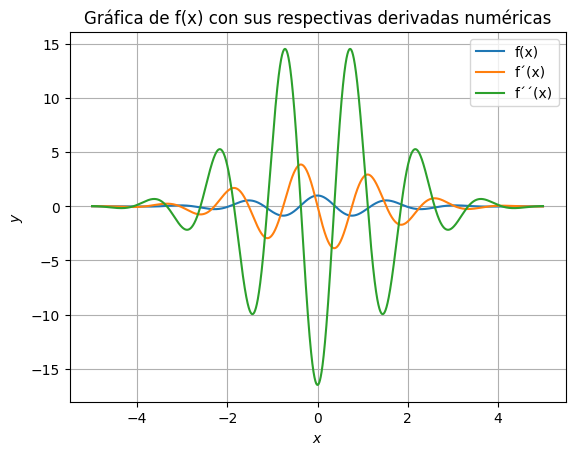

In [138]:
#Para f(x)
h = 1e-3
x = np.arange(-5,5,h)
f = np.exp(-(x/2)**2)*np.cos(4*x)
df_num = deriv_sim(f,x)
d2f_num = deriv_sim(df_num,x)
df_h4 = deriv_h5(f,x)   #Derivada del problema anterior
df = -4*np.exp(-(x/2)**2)*np.sin(4*x) - (x*np.exp(-(x/2)**2)*np.cos(4*x))/2
d2f = 4*x*-4*np.exp(-(x/2)**2)*np.sin(4*x) + (((x**2)-66)*np.exp(-(x/2)**2)*np.cos(4*x))/4

plt.plot(x,f, label=r'f(x)')
plt.plot(x,df_num, label="f´(x)")
plt.plot(x,d2f_num, label="f´´(x)")
plt.title('Gráfica de f(x) con sus respectivas derivadas numéricas')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')

plt.grid()
plt.legend()
plt.show()

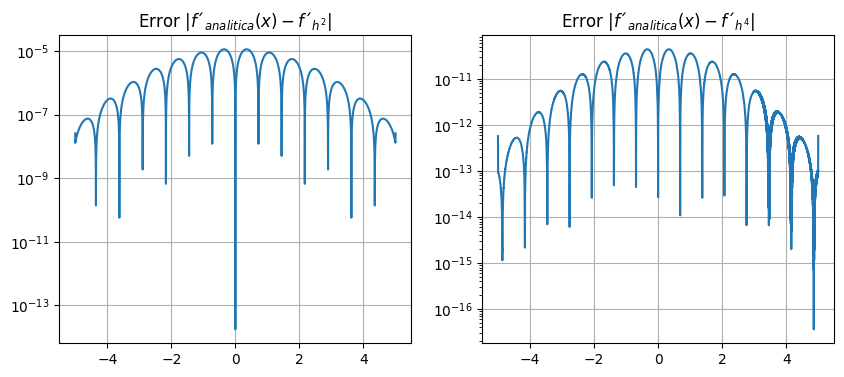

In [139]:
error2 = abs(df - df_num)
error4 = abs(df - df_h4)
fig, ejes = plt.subplots(1,2, figsize=(10,4))

#Para la derivada h2
ejes[0].semilogy(x,error2)
ejes[0].set_title('Error $|f´_{analitica}(x)-f´_{h^2}|$')
ejes[0].grid(True)
#Para la derivada h4
ejes[1].semilogy(x,error4)
ejes[1].set_title('Error $|f´_{analitica}(x)-f´_{h^4}|$')
ejes[1].grid(True)


plt.show()

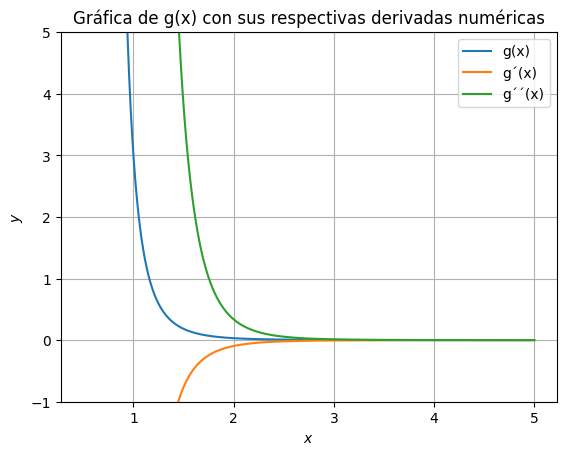

In [140]:
#Para g(x)
h = 1e-4
x = np.arange(0.5,5,h)
g = 2/x**6 + 1/x**12
dg_num = deriv_sim(g,x)
d2g_num = deriv_sim(dg_num,x)
dg_h4 = deriv_h5(g,x)   #Derivada del problema anterior
dg = -12/x**7 - 12/x**13
d2g = 84/x**8 + 156/x**14

plt.plot(x,g, label=r'g(x)')
plt.plot(x,dg_num, label="g´(x)")
plt.plot(x,d2g_num, label="g´´(x)")
plt.title('Gráfica de g(x) con sus respectivas derivadas numéricas')
plt.xlabel(r'$x$') , plt.ylabel(r'$y$')
plt.ylim([-1,5])

plt.grid()
plt.legend()
plt.show()

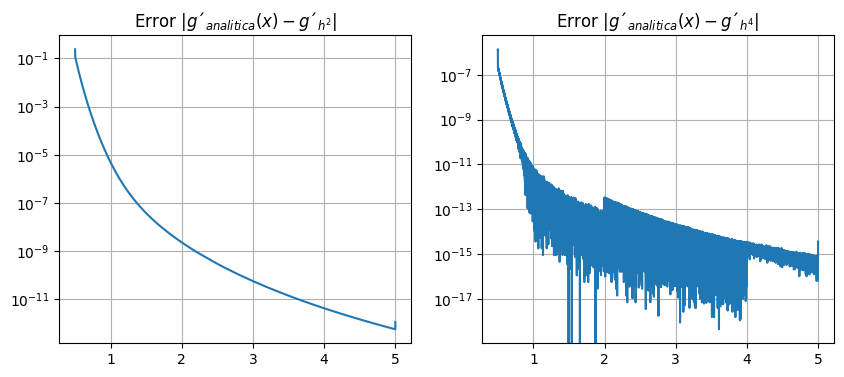

In [141]:
error2_g = abs(dg - dg_num)
error4_g = abs(dg - dg_h4)
fig, ejes = plt.subplots(1,2, figsize=(10,4))

#Para la derivada h2
ejes[0].semilogy(x,error2_g)
ejes[0].set_title('Error $|g´_{analitica}(x)-g´_{h^2}|$')
ejes[0].grid(True)
#Para la derivada h4
ejes[1].semilogy(x,error4_g)
ejes[1].set_title('Error $|g´_{analitica}(x)-g´_{h^4}|$')
ejes[1].grid(True)


plt.show()

Notas:
- No hice ningún empalme pues mi computadora no tuvo problema con valores chicos de h c: (sé que mejora el tiempo en el que se compila la celda)
- De hecho, traté de hacer empalmes para la comparación $|f´_{analitica}(x)-f´_{h^2}|$ pues el error queda $10^{-1}$ y esto provocaba que para $|f´_{analitica}(x)-f´_{h^4}|$ el error se disparara hasta $10^2$. Me imagino que algo hice mal por el camino; decidí mejor no incluir empalmes.
